In [1]:
print("Hello")

Hello


In [ ]:
"""
Enhanced Football Action Classification with Video Transformer
Combines temporal modeling, context-aware features, and advanced training techniques
"""

import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Memory optimization
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

# Configuration
CONFIG = {
    'data_path': '/kaggle/input/highlights',
    'model_name': 'swinv2_base_window12_192_22k',
    'num_classes': 5,
    'batch_size': 3,
    'gradient_accumulation_steps': 12,
    'num_epochs': 50,
    'learning_rate': 2e-5,
    'weight_decay': 0.02,
    'warmup_ratio': 0.15,
    'num_frames': 48,
    'img_size': 192,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    'save_path': 'football_action_model.pth',
    'mixed_precision': True,
    'early_stopping_patience': 6,
    'gradient_clipping': 1.5,
    'label_smoothing': 0.15,
    'dropout': 0.5,
    'freeze_backbone_epochs': 2,
    'videos_per_class': 300,
    'focal_loss_gamma': 2.5,
    'focal_loss_alpha': 0.75,
    'mixup_alpha': 0.3,
    'temporal_attention_heads': 8,  # Must divide feature_dim evenly
    'lstm_layers': 2,
    'hidden_multiplier': 2,
}


def clear_memory():
    """Aggressive memory clearing"""
    torch.cuda.empty_cache()
    gc.collect()


class AdaptiveFocalLoss(nn.Module):
    """Enhanced Focal Loss with adaptive weighting"""
    def __init__(self, alpha=0.75, gamma=2.5, label_smoothing=0.15):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def mixup_data(x, y, alpha=0.3):
    """Mixup augmentation for better generalization"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


class AdvancedVideoDataset(Dataset):
    """Enhanced dataset with sophisticated augmentation"""
    
    def __init__(self, video_paths, labels, num_frames=48, img_size=192, mode='train'):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.img_size = img_size
        self.mode = mode
        
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        
        if mode == 'train':
            self.spatial_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.35, hue=0.2),
                transforms.RandomGrayscale(p=0.15),
                transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 2.0))], p=0.2),
                transforms.ToTensor(),
            ])
        else:
            self.spatial_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
            ])
        
    def __len__(self):
        return len(self.video_paths)
    
    def extract_frames(self, video_path):
        """Intelligent frame extraction with temporal diversity"""
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames < self.num_frames:
            indices = np.linspace(0, max(1, total_frames - 1), total_frames, dtype=int)
            indices = np.tile(indices, (self.num_frames // len(indices)) + 1)[:self.num_frames]
        else:
            if self.mode == 'train':
                # Random temporal window with jittering
                segment_size = total_frames / self.num_frames
                indices = []
                for i in range(self.num_frames):
                    center = int((i + 0.5) * segment_size)
                    jitter = int(segment_size * 0.4)
                    start = max(0, center - jitter)
                    end = min(total_frames - 1, center + jitter)
                    indices.append(np.random.randint(start, end + 1))
                indices = np.array(indices)
            else:
                indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                if frames:
                    frames.append(frames[-1].copy())
        
        cap.release()
        
        while len(frames) < self.num_frames:
            frames.append(frames[-1].copy() if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        
        return frames[:self.num_frames]
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        frames = self.extract_frames(video_path)
        
        processed_frames = []
        for frame in frames:
            frame_tensor = self.spatial_transform(frame)
            frame_tensor = self.normalize(frame_tensor)
            processed_frames.append(frame_tensor)
        
        video_tensor = torch.stack(processed_frames)
        
        del frames, processed_frames
        
        return video_tensor, label


class ContextAwareTemporalModule(nn.Module):
    """Context-aware temporal modeling inspired by CALF"""
    def __init__(self, feature_dim, num_frames, dropout=0.3):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_frames = num_frames
        
        # Multi-scale temporal convolutions
        self.pyramid_1 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(feature_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout * 0.5)
        )
        self.pyramid_2 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=5, padding=2),
            nn.BatchNorm1d(feature_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout * 0.5)
        )
        self.pyramid_3 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=7, padding=3),
            nn.BatchNorm1d(feature_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout * 0.5)
        )
        self.pyramid_4 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=11, padding=5),
            nn.BatchNorm1d(feature_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim, kernel_size=1),
            nn.BatchNorm1d(feature_dim),
            nn.GELU()
        )
        
    def forward(self, x):
        # x: (batch, num_frames, feature_dim)
        x_t = x.transpose(1, 2)  # (batch, feature_dim, num_frames)
        
        p1 = self.pyramid_1(x_t)
        p2 = self.pyramid_2(x_t)
        p3 = self.pyramid_3(x_t)
        p4 = self.pyramid_4(x_t)
        
        pyramid_out = torch.cat([p1, p2, p3, p4], dim=1)
        fused = self.fusion(pyramid_out)
        
        return fused.transpose(1, 2)  # (batch, num_frames, feature_dim)


class EnhancedVideoTransformer(nn.Module):
    """Advanced video transformer with context-aware temporal modeling"""
    
    def __init__(self, model_name, num_classes, num_frames=48, dropout=0.5):
        super().__init__()
        self.num_frames = num_frames
        
        # Backbone
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        
        if hasattr(self.backbone, 'set_grad_checkpointing'):
            self.backbone.set_grad_checkpointing(enable=True)
        
        self.feature_dim = self.backbone.num_features
        print(f"✓ Backbone loaded: {model_name}, feature_dim={self.feature_dim}")
        
        # Context-aware temporal module
        self.context_temporal = ContextAwareTemporalModule(
            self.feature_dim, num_frames, dropout
        )
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=self.feature_dim // 2,
            num_layers=CONFIG['lstm_layers'],
            batch_first=True,
            bidirectional=True,
            dropout=dropout * 0.5 if CONFIG['lstm_layers'] > 1 else 0
        )
        
        # Multi-head self-attention (ensure heads divide feature_dim evenly)
        attention_heads = CONFIG['temporal_attention_heads']
        # Auto-adjust if feature_dim not divisible by num_heads
        while self.feature_dim % attention_heads != 0:
            attention_heads -= 1
        
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=self.feature_dim,
            num_heads=attention_heads,
            dropout=dropout * 0.5,
            batch_first=True
        )
        print(f"✓ Temporal attention: {attention_heads} heads")
        
        # Frame importance weighting
        self.frame_weights = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(self.feature_dim // 4, 1),
            nn.Sigmoid()
        )
        
        # Advanced classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, self.feature_dim * CONFIG['hidden_multiplier']),
            nn.GELU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(self.feature_dim * CONFIG['hidden_multiplier'], self.feature_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(self.feature_dim, self.feature_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.3),
            nn.Linear(self.feature_dim // 2, num_classes)
        )
        
    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
        
        # Extract spatial features
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        
        # Context-aware temporal modeling
        context_features = self.context_temporal(features)
        
        # LSTM processing
        lstm_out, _ = self.lstm(context_features)
        
        # Multi-head attention
        attended_features, attention_weights = self.temporal_attention(
            lstm_out, lstm_out, lstm_out
        )
        
        # Residual connections
        combined = features + context_features + lstm_out + attended_features
        
        # Frame importance weighting
        frame_importance = self.frame_weights(combined)
        weighted_features = combined * frame_importance
        
        # Temporal pooling (weighted average + max)
        avg_pool = weighted_features.mean(dim=1)
        max_pool, _ = weighted_features.max(dim=1)
        video_features = avg_pool + 0.3 * max_pool
        
        # Classification
        logits = self.classifier(video_features)
        
        return logits


def load_data(data_path, videos_per_class):
    """Load video paths and labels with balancing"""
    classes = ['foul', 'goal', 'freekick', 'penalty', 'corner']
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    video_paths = []
    labels = []
    
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if not os.path.exists(cls_path):
            print(f"⚠ Warning: {cls_path} does not exist")
            continue
        
        video_files = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi', '.mov'))]
        num_videos = len(video_files)
        print(f"✓ {cls}: Found {num_videos} videos")
        
        if num_videos >= videos_per_class:
            selected_files = np.random.choice(video_files, videos_per_class, replace=False).tolist()
        else:
            selected_files = video_files + list(np.random.choice(
                video_files, videos_per_class - num_videos, replace=True
            ))
        
        for video_file in selected_files:
            video_paths.append(os.path.join(cls_path, video_file))
            labels.append(class_to_idx[cls])
    
    print(f"\n✓ Total videos: {len(video_paths)} ({videos_per_class} per class)")
    return video_paths, labels, classes


def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler, accum_steps, epoch):
    """Enhanced training loop with mixup and dynamic freezing"""
    model.train()
    
    # Dynamic backbone freezing
    if epoch < CONFIG['freeze_backbone_epochs']:
        for param in model.backbone.parameters():
            param.requires_grad = False
    else:
        for param in model.backbone.parameters():
            param.requires_grad = True
    
    total_loss = 0
    correct = 0
    total = 0
    
    optimizer.zero_grad()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{CONFIG["num_epochs"]}')
    for batch_idx, (videos, labels) in enumerate(pbar):
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda', enabled=scaler is not None):
            # Apply mixup randomly
            if np.random.rand() < 0.5:
                videos, labels_a, labels_b, lam = mixup_data(videos, labels, CONFIG['mixup_alpha'])
                outputs = model(videos)
                loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            else:
                outputs = model(videos)
                loss = criterion(outputs, labels)
            
            loss = loss / accum_steps
        
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()
        
        if (batch_idx + 1) % accum_steps == 0:
            if scaler is not None:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clipping'])
            
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            
            optimizer.zero_grad()
            scheduler.step()
            
            if (batch_idx + 1) % (accum_steps * 5) == 0:
                clear_memory()
        
        total_loss += loss.item() * accum_steps
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        del videos, labels, outputs, loss
        
        pbar.set_postfix({
            'loss': f'{total_loss / (batch_idx + 1):.4f}',
            'acc': f'{100. * correct / total:.2f}%',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })
    
    clear_memory()
    return total_loss / len(dataloader), 100. * correct / total


def validate(model, dataloader, criterion, device):
    """Validation loop"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc='Validation'):
            videos = videos.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            del videos, labels, outputs, loss
    
    clear_memory()
    return total_loss / len(dataloader), 100. * correct / total, all_preds, all_labels


def plot_results(history, cm, classes):
    """Comprehensive results visualization"""
    fig = plt.figure(figsize=(20, 5))
    
    # Loss plot
    ax1 = plt.subplot(141)
    ax1.plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
    
    # Accuracy plot
    ax2 = plt.subplot(142)
    ax2.plot(history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    
    # Confusion Matrix (counts)
    ax3 = plt.subplot(143)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
                xticklabels=classes, yticklabels=classes, cbar=False)
    ax3.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('True Label', fontsize=12)
    ax3.set_xlabel('Predicted Label', fontsize=12)
    
    # Confusion Matrix (normalized)
    ax4 = plt.subplot(144)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax4,
                xticklabels=classes, yticklabels=classes, cbar=False)
    ax4.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('True Label', fontsize=12)
    ax4.set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
    plt.show()


def main():
    """Main training pipeline"""
    clear_memory()
    
    # Set seeds
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    
    print(f"\n{'='*70}")
    print(f"🚀 FOOTBALL ACTION CLASSIFICATION TRAINING")
    print(f"{'='*70}")
    print(f"Device: {CONFIG['device']}")
    if CONFIG['device'] == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"{'='*70}\n")
    
    # Load data
    print("📂 Loading dataset...")
    video_paths, labels, classes = load_data(CONFIG['data_path'], CONFIG['videos_per_class'])
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        video_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    print(f"\n✓ Dataset split:")
    print(f"  - Train: {len(train_paths)} videos")
    print(f"  - Val: {len(val_paths)} videos")
    
    # Create datasets
    train_dataset = AdvancedVideoDataset(
        train_paths, train_labels, CONFIG['num_frames'], CONFIG['img_size'], mode='train'
    )
    val_dataset = AdvancedVideoDataset(
        val_paths, val_labels, CONFIG['num_frames'], CONFIG['img_size'], mode='val'
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['num_workers'],
        pin_memory=True,
        drop_last=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=CONFIG['num_workers'],
        pin_memory=True
    )
    
    # Initialize model
    print(f"\n🔧 Building model...")
    model = EnhancedVideoTransformer(
        CONFIG['model_name'],
        CONFIG['num_classes'],
        CONFIG['num_frames'],
        CONFIG['dropout']
    ).to(CONFIG['device'])
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✓ Total parameters: {total_params:,}")
    print(f"✓ Trainable parameters: {trainable_params:,}")
    
    # Loss and optimizer
    criterion = AdaptiveFocalLoss(
        alpha=CONFIG['focal_loss_alpha'],
        gamma=CONFIG['focal_loss_gamma'],
        label_smoothing=CONFIG['label_smoothing']
    )
    
    optimizer = torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': CONFIG['learning_rate'] * 0.1},
        {'params': model.context_temporal.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.lstm.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.temporal_attention.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.frame_weights.parameters(), 'lr': CONFIG['learning_rate'] * 1.5},
        {'params': model.classifier.parameters(), 'lr': CONFIG['learning_rate'] * 2},
    ], weight_decay=CONFIG['weight_decay'])
    
    total_steps = (len(train_loader) // CONFIG['gradient_accumulation_steps']) * CONFIG['num_epochs']
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[CONFIG['learning_rate'] * 0.1, CONFIG['learning_rate'],
                CONFIG['learning_rate'], CONFIG['learning_rate'],
                CONFIG['learning_rate'] * 1.5, CONFIG['learning_rate'] * 2],
        total_steps=total_steps,
        pct_start=CONFIG['warmup_ratio'],
        anneal_strategy='cos',
        div_factor=25,
        final_div_factor=1000
    )
    
    scaler = torch.amp.GradScaler('cuda') if CONFIG['mixed_precision'] and CONFIG['device'] == 'cuda' else None
    
    # Training loop
    best_acc = 0
    early_stop_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"\n{'='*70}")
    print("🎯 Starting training...")
    print(f"{'='*70}\n")
    
    for epoch in range(CONFIG['num_epochs']):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            CONFIG['device'], scaler, CONFIG['gradient_accumulation_steps'], epoch
        )
        
        clear_memory()
        
        val_loss, val_acc, val_preds, val_labels_list = validate(
            model, val_loader, criterion, CONFIG['device']
        )
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"\n📊 Epoch {epoch+1}/{CONFIG['num_epochs']} Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'config': CONFIG
            }, CONFIG['save_path'])
            print(f"  ✓ Best model saved! (Acc: {best_acc:.2f}%)")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"  ⏳ No improvement ({early_stop_counter}/{CONFIG['early_stopping_patience']})")
            if early_stop_counter >= CONFIG['early_stopping_patience']:
                print("\n⚠ Early stopping triggered!")
                break
        
        clear_memory()
    
    # Final evaluation
    print(f"\n{'='*70}")
    print("📈 FINAL EVALUATION")
    print(f"{'='*70}\n")
    
    checkpoint = torch.load(CONFIG['save_path'])
    model.load_state_dict(checkpoint['model_state_dict'])
    
    _, _, final_preds, final_labels = validate(model, val_loader, criterion, CONFIG['device'])
    
    print(classification_report(final_labels, final_preds, target_names=classes, digits=4))
    
    cm = confusion_matrix(final_labels, final_preds)
    plot_results(history, cm, classes)
    
    print(f"\n{'='*70}")
    print(f"✅ Training completed!")
    print(f"   Best validation accuracy: {best_acc:.2f}%")
    print(f"   Model saved: {CONFIG['save_path']}")
    print(f"{'='*70}\n")


if __name__ == "__main__":
    main()


🚀 FOOTBALL ACTION CLASSIFICATION TRAINING
Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.06 GB

📂 Loading dataset...
✓ foul: Found 300 videos
✓ goal: Found 211 videos
✓ freekick: Found 374 videos
✓ penalty: Found 322 videos
✓ corner: Found 411 videos

✓ Total videos: 1500 (300 per class)

✓ Dataset split:
  - Train: 1200 videos
  - Val: 300 videos

🔧 Building model...
✓ Backbone loaded: swinv2_base_window12_192_22k, feature_dim=1024
✓ Temporal attention: 8 heads
✓ Total parameters: 116,551,422
✓ Trainable parameters: 116,551,422

🎯 Starting training...



Epoch 1/50:  54%|█████▎    | 214/400 [12:26<09:49,  3.17s/it, loss=0.6900, acc=21.50%, lr=1.02e-07]

In [ ]:
# import tensorflow as tf
# from numba import cuda
# import gc

# # Clear TF session (works in TF 2.x)
# tf.keras.backend.clear_session()

# # Close CUDA device
# cuda.select_device(0)
# cuda.close()

# # Run garbage collection
# gc.collect()

In [ ]:
# !nvidia-smi

In [ ]:
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
# import cv2
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import gc
# import numpy as np
# from torchvision import transforms
# import timm

# # Configuration matching the training script
# CONFIG = {
#     'model_name': 'swin_small_patch4_window7_224',
#     'num_classes': 5,
#     'num_frames': 16,  # Must match training config
#     'img_size': 224,
#     'mixed_precision': True,
#     'dropout': 0.3,
# }


# class VideoSwinTransformer(nn.Module):
#     """Same architecture as training - must match exactly"""
    
#     def __init__(self, model_name, num_classes, num_frames=16, dropout=0.3):
#         super().__init__()
#         self.num_frames = num_frames
        
#         # Load pretrained Swin Transformer
#         self.backbone = timm.create_model(
#             model_name,
#             pretrained=True,
#             num_classes=0,
#             global_pool=''
#         )
        
#         self.feature_dim = self.backbone.num_features
        
#         # Temporal modeling layers
#         self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(self.feature_dim, self.feature_dim, kernel_size=3, padding=1),
#             nn.BatchNorm1d(self.feature_dim),
#             nn.ReLU(inplace=True),
#             nn.Dropout(dropout * 0.5)
#         )
        
#         self.lstm = nn.LSTM(
#             input_size=self.feature_dim,
#             hidden_size=self.feature_dim // 2,
#             num_layers=2,
#             batch_first=True,
#             bidirectional=True,
#             dropout=dropout * 0.5 if dropout > 0 else 0
#         )
        
#         self.temporal_attention = nn.MultiheadAttention(
#             embed_dim=self.feature_dim,
#             num_heads=8,
#             dropout=dropout * 0.5,
#             batch_first=True
#         )
        
#         self.classifier = nn.Sequential(
#             nn.LayerNorm(self.feature_dim),
#             nn.Dropout(dropout),
#             nn.Linear(self.feature_dim, self.feature_dim // 2),
#             nn.GELU(),
#             nn.Dropout(dropout * 0.5),
#             nn.Linear(self.feature_dim // 2, num_classes)
#         )
        
#     def forward(self, x):
#         # x: [B, T, C, H, W]
#         batch_size, num_frames, c, h, w = x.shape
#         x = x.view(batch_size * num_frames, c, h, w)
        
#         # Extract spatial features
#         features = self.backbone(x)
        
#         if len(features.shape) == 4:
#             features = features.mean(dim=[1, 2])
        
#         features = features.view(batch_size, num_frames, -1)
        
#         # Temporal convolution
#         temp_conv_out = self.temporal_conv(features.transpose(1, 2))
#         temp_conv_out = temp_conv_out.transpose(1, 2)
        
#         # LSTM
#         lstm_out, _ = self.lstm(temp_conv_out)
        
#         # Temporal attention
#         attended_features, _ = self.temporal_attention(
#             lstm_out, lstm_out, lstm_out
#         )
        
#         # Combine features
#         combined_features = lstm_out + attended_features
        
#         # Temporal pooling
#         video_features = combined_features.mean(dim=1)
        
#         # Classification
#         logits = self.classifier(video_features)
        
#         return logits


# def predict_consecutive_chunks_gpu(video_path, model_path, chunk_size=30, threshold=0.7):
#     """
#     Load the trained Video Swin model and make predictions on consecutive chunks
#     from the input video using GPU.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#         chunk_size (int): Number of frames per chunk (default: 30).
#         threshold (float): Probability threshold to consider it an event (default: 0.7).
#     """
#     # Verify GPU availability
#     if not torch.cuda.is_available():
#         print("Warning: GPU not available. Using CPU (will be slower).")
#         device = 'cpu'
#     else:
#         device = 'cuda'
#         print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
#         print(f"✓ Available GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

#     print(f"\n{'='*60}")
#     print("LOADING MODEL")
#     print(f"{'='*60}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     print(f"✓ Model loaded from: {model_path}")
#     print(f"✓ Best validation accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")
    
#     # Preprocessing transforms (same as training)
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     # Class names
#     classes = ['foul', 'goal', 'freekick', 'penalty', 'corner']
    
#     print(f"\n{'='*60}")
#     print("PROCESSING VIDEO")
#     print(f"{'='*60}")
    
#     # Open video
#     cap = cv2.VideoCapture(video_path)
#     if not cap.isOpened():
#         print(f"Error: Could not open video {video_path}")
#         return
    
#     # Get video properties
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#     video_duration = total_frames / fps if fps > 0 else 0
    
#     print(f"Video: {video_path}")
#     print(f"Resolution: {width}x{height}")
#     print(f"FPS: {fps:.2f}")
#     print(f"Total frames: {total_frames}")
#     print(f"Duration: {video_duration:.2f} seconds")
#     print(f"Processing in chunks of {chunk_size} frames")
#     print(f"Model expects {CONFIG['num_frames']} frames per prediction")
#     print(f"Confidence threshold: {threshold}")
    
#     print(f"\n{'='*60}")
#     print("PREDICTIONS")
#     print(f"{'='*60}")
    
#     chunk_count = 0
#     event_count = 0
    
#     with torch.no_grad():
#         while cap.isOpened():
#             chunk_count += 1
#             start_frame = (chunk_count - 1) * chunk_size
#             end_frame = min(start_frame + chunk_size, total_frames)
            
#             if start_frame >= total_frames:
#                 break
            
#             # Extract chunk_size frames
#             frames = []
#             for idx in range(start_frame, end_frame):
#                 cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#                 ret, frame = cap.read()
#                 if ret:
#                     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                     frames.append(frame)
            
#             if not frames:
#                 break
            
#             # Resample to exactly CONFIG['num_frames'] frames
#             num_extracted = len(frames)
#             if num_extracted < CONFIG['num_frames']:
#                 # Pad by repeating last frame
#                 while len(frames) < CONFIG['num_frames']:
#                     frames.append(frames[-1])
#             elif num_extracted > CONFIG['num_frames']:
#                 # Uniformly sample CONFIG['num_frames'] frames
#                 indices = np.linspace(0, num_extracted - 1, CONFIG['num_frames'], dtype=int)
#                 frames = [frames[i] for i in indices]
            
#             # Process frames
#             processed_frames = []
#             for frame in frames:
#                 frame_tensor = transform(frame)
#                 frame_tensor = normalize(frame_tensor)
#                 processed_frames.append(frame_tensor)
            
#             # Stack frames: (1, T, C, H, W)
#             frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
            
#             # Forward pass with mixed precision
#             if CONFIG['mixed_precision'] and device == 'cuda':
#                 with torch.amp.autocast('cuda'):
#                     logits = model(frame_tensor)
#             else:
#                 logits = model(frame_tensor)
            
#             # Compute probabilities
#             probs = F.softmax(logits, dim=1)[0]
#             max_prob, pred_idx = torch.max(probs, dim=0)
#             pred_class = classes[pred_idx.item()]
            
#             # Calculate time stamps
#             start_time = start_frame / fps if fps > 0 else 0
#             end_time = min(end_frame / fps, video_duration) if fps > 0 else 0
            
#             # Print prediction
#             if max_prob.item() >= threshold:
#                 print(f"🎯 Chunk {chunk_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Frames {start_frame+1:5d}-{end_frame:5d} | "
#                       f"Event: {pred_class.upper():10s} | Confidence: {max_prob.item():.1%}")
#                 event_count += 1
#             else:
#                 print(f"⚪ Chunk {chunk_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Frames {start_frame+1:5d}-{end_frame:5d} | "
#                       f"No event (max: {max_prob.item():.1%})")
            
#             # Show all class probabilities for events
#             if max_prob.item() >= threshold:
#                 print(f"   └─ Probabilities: ", end="")
#                 for i, cls in enumerate(classes):
#                     print(f"{cls}: {probs[i].item():.1%}", end="  ")
#                 print()
            
#             # Clear GPU cache periodically
#             if chunk_count % 10 == 0 and device == 'cuda':
#                 torch.cuda.empty_cache()
#                 gc.collect()
    
#     cap.release()
    
#     print(f"\n{'='*60}")
#     print("SUMMARY")
#     print(f"{'='*60}")
#     print(f"Total chunks processed: {chunk_count}")
#     print(f"Total frames processed: {total_frames}")
#     print(f"Events detected (≥{threshold:.0%} confidence): {event_count}")
#     print(f"Event rate: {event_count/chunk_count*100:.1f}% of chunks")
#     print("✓ Prediction complete!")
#     print(f"{'='*60}")


# def predict_single_video(video_path, model_path):
#     """
#     Make a single prediction on the entire video (sampling to CONFIG['num_frames']).
#     Useful for short clips or highlight videos.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#     """
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     print(f"Using device: {device}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     # Preprocessing
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     classes = ['foul', 'goal', 'freekick', 'penalty']
    
#     # Open video and extract frames
#     cap = cv2.VideoCapture(video_path)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     fps = cap.get(cv2.CAP_PROP_FPS)
    
#     print(f"\nProcessing: {video_path}")
#     print(f"Total frames: {total_frames}, FPS: {fps:.2f}")
    
#     # Sample frames uniformly
#     indices = np.linspace(0, total_frames - 1, CONFIG['num_frames'], dtype=int)
#     frames = []
    
#     for idx in indices:
#         cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#         ret, frame = cap.read()
#         if ret:
#             frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#             frames.append(frame)
    
#     cap.release()
    
#     if len(frames) < CONFIG['num_frames']:
#         while len(frames) < CONFIG['num_frames']:
#             frames.append(frames[-1])
    
#     # Process frames
#     processed_frames = []
#     for frame in frames:
#         frame_tensor = transform(frame)
#         frame_tensor = normalize(frame_tensor)
#         processed_frames.append(frame_tensor)
    
#     frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
    
#     # Predict
#     with torch.no_grad():
#         if CONFIG['mixed_precision'] and device == 'cuda':
#             with torch.amp.autocast('cuda'):
#                 logits = model(frame_tensor)
#         else:
#             logits = model(frame_tensor)
        
#         probs = F.softmax(logits, dim=1)[0]
#         max_prob, pred_idx = torch.max(probs, dim=0)
#         pred_class = classes[pred_idx.item()]
    
#     print(f"\n{'='*60}")
#     print(f"PREDICTION: {pred_class.upper()}")
#     print(f"Confidence: {max_prob.item():.1%}")
#     print(f"{'='*60}")
#     print("All class probabilities:")
#     for i, cls in enumerate(classes):
#         print(f"  {cls:10s}: {probs[i].item():.1%} {'█' * int(probs[i].item() * 50)}")
#     print(f"{'='*60}")


# def predict_with_sliding_window(video_path, model_path, window_size=16, stride=8, threshold=0.7):
#     """
#     Make predictions using a sliding window approach for more granular detection.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#         window_size (int): Number of frames per window (should match CONFIG['num_frames']).
#         stride (int): Number of frames to slide the window (smaller = more overlap).
#         threshold (float): Probability threshold to consider it an event.
#     """
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     print(f"✓ Using device: {device}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     print(f"✓ Model loaded with accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")
    
#     # Preprocessing
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     classes = ['foul', 'goal', 'freekick', 'penalty']
    
#     # Open video
#     cap = cv2.VideoCapture(video_path)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     fps = cap.get(cv2.CAP_PROP_FPS)
    
#     print(f"\n{'='*60}")
#     print("SLIDING WINDOW PREDICTION")
#     print(f"{'='*60}")
#     print(f"Video: {video_path}")
#     print(f"Total frames: {total_frames}, FPS: {fps:.2f}")
#     print(f"Window size: {window_size}, Stride: {stride}")
#     print(f"Threshold: {threshold}")
#     print(f"{'='*60}\n")
    
#     event_count = 0
#     window_count = 0
    
#     with torch.no_grad():
#         for start_idx in range(0, total_frames - window_size + 1, stride):
#             window_count += 1
#             end_idx = start_idx + window_size
            
#             # Extract frames for this window
#             frames = []
#             for idx in range(start_idx, end_idx):
#                 cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#                 ret, frame = cap.read()
#                 if ret:
#                     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                     frames.append(frame)
            
#             if len(frames) < window_size:
#                 continue
            
#             # Process frames
#             processed_frames = []
#             for frame in frames:
#                 frame_tensor = transform(frame)
#                 frame_tensor = normalize(frame_tensor)
#                 processed_frames.append(frame_tensor)
            
#             frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
            
#             # Predict
#             if CONFIG['mixed_precision'] and device == 'cuda':
#                 with torch.amp.autocast('cuda'):
#                     logits = model(frame_tensor)
#             else:
#                 logits = model(frame_tensor)
            
#             probs = F.softmax(logits, dim=1)[0]
#             max_prob, pred_idx = torch.max(probs, dim=0)
#             pred_class = classes[pred_idx.item()]
            
#             start_time = start_idx / fps
#             end_time = end_idx / fps
            
#             if max_prob.item() >= threshold:
#                 print(f"🎯 Window {window_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Event: {pred_class.upper():10s} | Confidence: {max_prob.item():.1%}")
#                 event_count += 1
            
#             # Clear cache periodically
#             if window_count % 20 == 0 and device == 'cuda':
#                 torch.cuda.empty_cache()
    
#     cap.release()
    
#     print(f"\n{'='*60}")
#     print(f"Total windows: {window_count}")
#     print(f"Events detected: {event_count}")
#     print(f"{'='*60}")


# # Example usage
# if __name__ == "__main__":
#     # Option 1: Process video in chunks (recommended for long videos)
#     # print("="*60)
#     # print("OPTION 1: CHUNK-BASED PREDICTION")
#     # print("="*60)
#     # predict_consecutive_chunks_gpu(
#     #     video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#     #     model_path='/kaggle/input/swin-model/best_video_swin_model.pth',
#     #     chunk_size=30,
#     #     threshold=0.7
#     # )
    
#     # Option 2: Single prediction for entire video (better for short clips)
#     print("\n" + "="*60)
#     print("OPTION 2: SINGLE VIDEO PREDICTION")

#     print("="*60)
#     predict_single_video(
#         video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#         model_path='/kaggle/input/swisss/best_video_swin_model (1).pth'
#     )
    
#     # Option 3: Sliding window with overlap (most thorough)
#     # print("\n" + "="*60)
#     # print("OPTION 3: SLIDING WINDOW PREDICTION")
#     # print("="*60)
#     # predict_with_sliding_window(
#     #     video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#     #     model_path='/kaggle/input/swin-model/best_video_swin_model.pth',
#     #     window_size=16,  # Match CONFIG['num_frames']
#     #     stride=8,        # 50% overlap
#     #     threshold=0.7
#     # )

In [3]:
pip install gdown
est_paths, test_labels = load_test_data(CONFIG['data_path'])

Note: you may need to restart the kernel to use updated packages.


In [4]:
!gdown --id 1GStgg3zr2BpG6qiARFbl6xJOsSn_kjG8

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1GStgg3zr2BpG6qiARFbl6xJOsSn_kjG8

but Gdown can't. Please check connections and permissions.


## best_video_swin_model_CALF_20_epoch.pth

✓ Model already exists at /kaggle/working/football_action_model.pth, skipping download.

🏆  FOOTBALL ACTION MODEL - TESTING
Device : cuda
GPU    : Tesla P100-PCIE-16GB

🔧 Loading model...
✓ Loaded checkpoint  — epoch 16, val_acc 86.33333333333333

📂 Loading test data...
  foul: 100 videos selected
  goal: 100 videos selected
  freekick: 100 videos selected
  penalty: 100 videos selected
  corner: 100 videos selected
  Total: 500 videos (100 per class)



Running inference: 100%|██████████| 125/125 [08:50<00:00,  4.25s/it]



📊  FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        foul     1.0000    0.7800    0.8764       100
        goal     1.0000    0.9700    0.9848       100
    freekick     0.7165    0.9100    0.8018       100
     penalty     0.7674    0.9900    0.8646       100
      corner     0.9710    0.6700    0.7929       100

    accuracy                         0.8640       500
   macro avg     0.8910    0.8640    0.8641       500
weighted avg     0.8910    0.8640    0.8641       500

  Overall Accuracy      : 86.4000%
  Weighted Precision    : 89.0998%
  Weighted Recall       : 86.4000%
  Weighted F1-Score     : 86.4093%
  Macro Precision       : 89.0998%
  Macro Recall          : 86.4000%
  Macro F1-Score        : 86.4093%

📌  PER-CLASS METRICS
Class         Precision     Recall         F1    Support
-------------------------------------------------------
foul            100.00%     78.00%     87.64%        100
goal            100.00%     97.00%     98.4

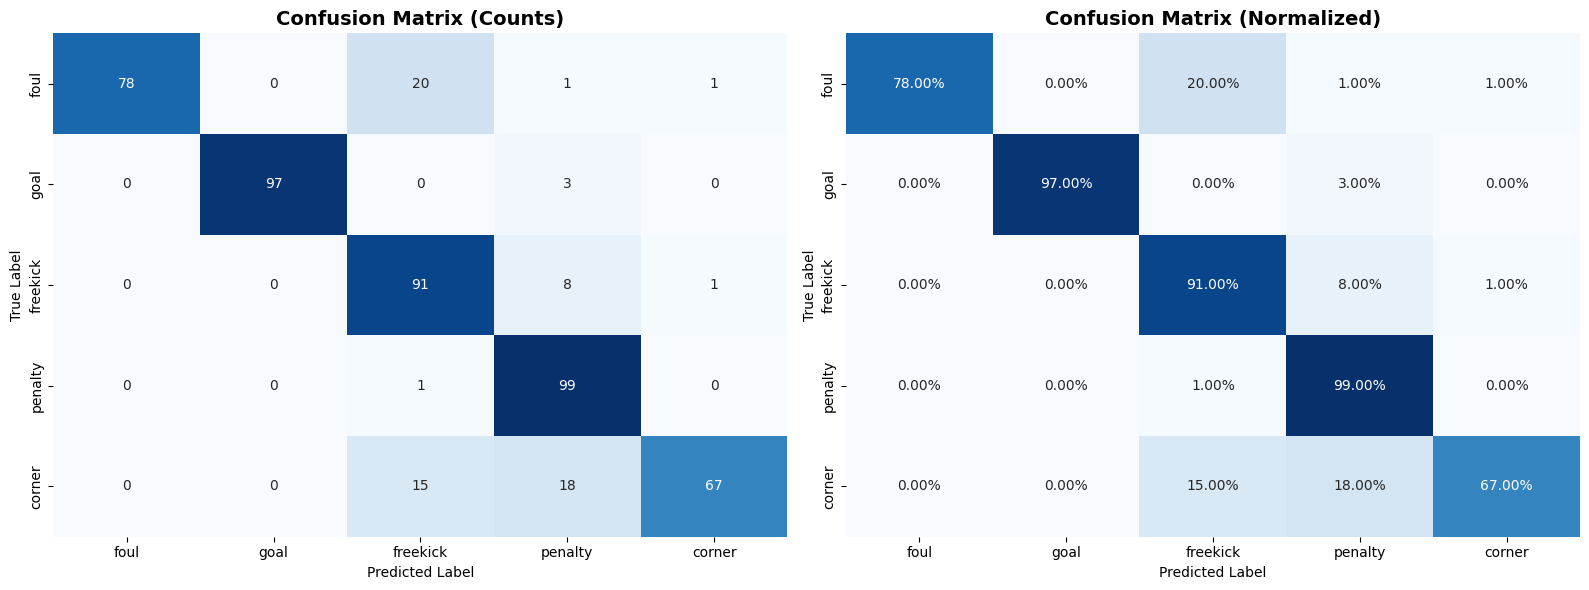

✓ Saved: test_confusion_matrix.png


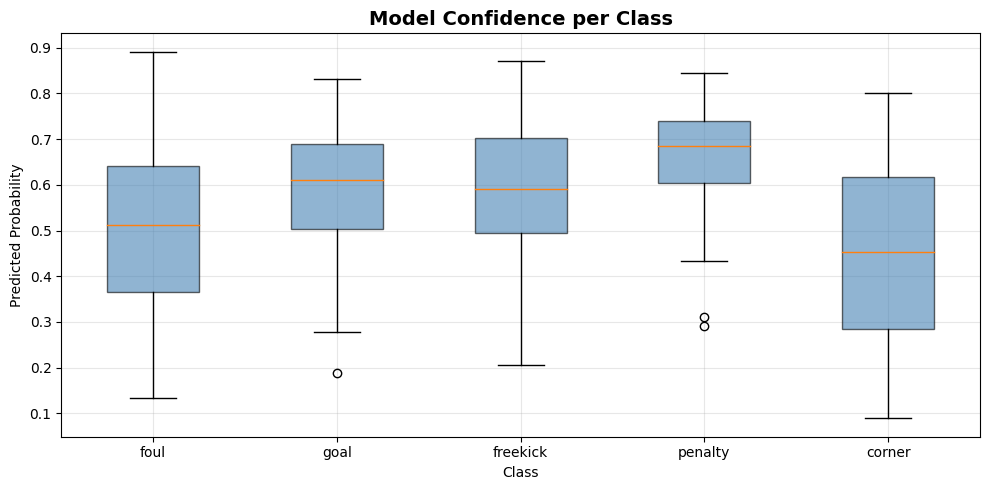

✓ Saved: test_confidence.png

✅  Testing complete!



In [7]:
"""
Football Action Classification - Model Testing Script
Tests saved model on validation/test data and prints full metrics
"""

import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1.  DOWNLOAD MODEL FROM GOOGLE DRIVE
# ─────────────────────────────────────────────
# Paste your Google Drive shareable link file-id below
# e.g. https://drive.google.com/file/d/FILE_ID/view?usp=sharing  →  FILE_ID
DRIVE_SHARE_URL = "https://drive.google.com/file/d/1-Q4IwS6G1UGNTA0q7y6I6Lq4FxSnpuuQ/view?usp=sharing"
MODEL_SAVE_PATH = "/kaggle/working/football_action_model.pth"

def download_model_from_drive(share_url, output_path):
    if os.path.exists(output_path):
        print(f"✓ Model already exists at {output_path}, skipping download.")
        return
    print("📥 Downloading model from Google Drive...")
    os.system('pip install -q gdown --upgrade')
    import gdown
    # fuzzy=True handles /view?usp=sharing URLs directly
    gdown.download(share_url, output_path, quiet=False, fuzzy=True)
    if not os.path.exists(output_path):
        raise RuntimeError(
            "Download failed. Please go to your Google Drive file → Share → "
            "Change to 'Anyone with the link' → Copy link, then update DRIVE_SHARE_URL."
        )
    print(f"✓ Model downloaded to {output_path}")

download_model_from_drive(DRIVE_SHARE_URL, MODEL_SAVE_PATH)


# ─────────────────────────────────────────────
# 2.  CONFIG  (must match training config)
# ─────────────────────────────────────────────
CONFIG = {
    'data_path': '/kaggle/input/highlights',
    'model_name': 'swinv2_base_window12_192_22k',
    'num_classes': 5,
    'num_frames': 48,
    'img_size': 192,
    'batch_size': 4,           # increase if your GPU has room
    'num_workers': 2,
    'dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'temporal_attention_heads': 8,
    'lstm_layers': 2,
    'hidden_multiplier': 2,
    'focal_loss_gamma': 2.5,
    'focal_loss_alpha': 0.75,
    'label_smoothing': 0.15,
}

CLASSES = ['foul', 'goal', 'freekick', 'penalty', 'corner']


# ─────────────────────────────────────────────
# 3.  MODEL ARCHITECTURE  (copy from training)
# ─────────────────────────────────────────────

class ContextAwareTemporalModule(nn.Module):
    def __init__(self, feature_dim, num_frames, dropout=0.3):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_frames = num_frames
        # Named pyramid_1/2/3/4 to match training checkpoint keys
        self.pyramid_1 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_2 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=5, padding=2),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_3 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=7, padding=3),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_4 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=11, padding=5),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.fusion = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim, kernel_size=1),
            nn.BatchNorm1d(feature_dim), nn.GELU()
        )

    def forward(self, x):
        x_t = x.transpose(1, 2)
        p1 = self.pyramid_1(x_t)
        p2 = self.pyramid_2(x_t)
        p3 = self.pyramid_3(x_t)
        p4 = self.pyramid_4(x_t)
        return self.fusion(torch.cat([p1, p2, p3, p4], dim=1)).transpose(1, 2)


class EnhancedVideoTransformer(nn.Module):
    def __init__(self, model_name, num_classes, num_frames=48, dropout=0.5):
        super().__init__()
        self.num_frames = num_frames
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0, global_pool='avg')
        self.feature_dim = self.backbone.num_features

        self.context_temporal = ContextAwareTemporalModule(self.feature_dim, num_frames, dropout)

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=self.feature_dim // 2,
            num_layers=CONFIG['lstm_layers'],
            batch_first=True, bidirectional=True,
            dropout=dropout * 0.5 if CONFIG['lstm_layers'] > 1 else 0
        )

        heads = CONFIG['temporal_attention_heads']
        while self.feature_dim % heads != 0:
            heads -= 1
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=self.feature_dim, num_heads=heads,
            dropout=dropout * 0.5, batch_first=True
        )

        self.frame_weights = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim // 4), nn.GELU(),
            nn.Dropout(dropout * 0.5), nn.Linear(self.feature_dim // 4, 1), nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim), nn.Dropout(dropout),
            nn.Linear(self.feature_dim, self.feature_dim * CONFIG['hidden_multiplier']),
            nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(self.feature_dim * CONFIG['hidden_multiplier'], self.feature_dim),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(self.feature_dim, self.feature_dim // 2),
            nn.GELU(), nn.Dropout(dropout * 0.3),
            nn.Linear(self.feature_dim // 2, num_classes)
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        features = self.backbone(x.view(b * t, c, h, w)).view(b, t, -1)
        ctx = self.context_temporal(features)
        lstm_out, _ = self.lstm(ctx)
        attn_out, _ = self.temporal_attention(lstm_out, lstm_out, lstm_out)
        combined = features + ctx + lstm_out + attn_out
        w = self.frame_weights(combined)
        weighted = combined * w
        pooled = weighted.mean(dim=1) + 0.3 * weighted.max(dim=1).values
        return self.classifier(pooled)


# ─────────────────────────────────────────────
# 4.  DATASET
# ─────────────────────────────────────────────

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=48, img_size=192):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.video_paths)

    def extract_frames(self, path):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, max(1, total - 1), self.num_frames, dtype=int)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            elif frames:
                frames.append(frames[-1].copy())
        cap.release()
        while len(frames) < self.num_frames:
            frames.append(frames[-1].copy() if frames else
                          np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        return frames[:self.num_frames]

    def __getitem__(self, idx):
        frames = self.extract_frames(self.video_paths[idx])
        tensor = torch.stack([self.transform(f) for f in frames])
        return tensor, self.labels[idx]


# ─────────────────────────────────────────────
# 5.  LOAD TEST DATA
# ─────────────────────────────────────────────

def load_test_data(data_path, videos_per_class=100):
    """Load exactly 100 videos per class for testing."""
    class_to_idx = {cls: idx for idx, cls in enumerate(CLASSES)}
    paths, labels = [], []
    
    np.random.seed(42)  # reproducible selection
    
    for cls in CLASSES:
        cls_path = os.path.join(data_path, cls)
        if not os.path.exists(cls_path):
            print(f"⚠ Missing: {cls_path}")
            continue
        
        videos = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi', '.mov'))]
        
        if len(videos) >= videos_per_class:
            selected = np.random.choice(videos, videos_per_class, replace=False).tolist()
        else:
            # if less than 100 available, take all and oversample
            selected = videos + np.random.choice(videos, videos_per_class - len(videos), replace=True).tolist()
            print(f"  ⚠ {cls}: only {len(videos)} available, oversampled to {videos_per_class}")
        
        print(f"  {cls}: {len(selected)} videos selected")
        for v in selected:
            paths.append(os.path.join(cls_path, v))
            labels.append(class_to_idx[cls])
    
    print(f"  Total: {len(paths)} videos ({videos_per_class} per class)\n")
    return paths, labels


# ─────────────────────────────────────────────
# 6.  INFERENCE
# ─────────────────────────────────────────────

def run_inference(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for videos, labels in tqdm(loader, desc='Running inference'):
            videos = videos.to(device, non_blocking=True)
            outputs = model(videos)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            del videos, outputs
            torch.cuda.empty_cache()
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


# ─────────────────────────────────────────────
# 7.  METRICS + PLOTS
# ─────────────────────────────────────────────

def print_metrics(preds, labels, probs):
    print("\n" + "="*70)
    print("📊  FULL CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(labels, preds, target_names=CLASSES, digits=4))

    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro')

    print("="*70)
    print(f"  Overall Accuracy      : {acc*100:.4f}%")
    print(f"  Weighted Precision    : {p*100:.4f}%")
    print(f"  Weighted Recall       : {r*100:.4f}%")
    print(f"  Weighted F1-Score     : {f1*100:.4f}%")
    print(f"  Macro Precision       : {p_macro*100:.4f}%")
    print(f"  Macro Recall          : {r_macro*100:.4f}%")
    print(f"  Macro F1-Score        : {f1_macro*100:.4f}%")
    print("="*70)

    # Per-class breakdown
    print("\n📌  PER-CLASS METRICS")
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-"*55)
    p_c, r_c, f1_c, sup = precision_recall_fscore_support(labels, preds, average=None)
    for i, cls in enumerate(CLASSES):
        print(f"{cls:<12} {p_c[i]*100:>9.2f}%  {r_c[i]*100:>8.2f}%  {f1_c[i]*100:>8.2f}%  {int(sup[i]):>9}")


def plot_confusion_matrices(preds, labels):
    cm = confusion_matrix(labels, preds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('test_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: test_confusion_matrix.png")


def plot_class_confidence(probs, labels):
    """Box plot of model confidence per class."""
    fig, ax = plt.subplots(figsize=(10, 5))
    data = [probs[labels == i, i] for i in range(len(CLASSES))]
    ax.boxplot(data, labels=CLASSES, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title('Model Confidence per Class', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Probability'); ax.set_xlabel('Class')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('test_confidence.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: test_confidence.png")


# ─────────────────────────────────────────────
# 8.  MAIN
# ─────────────────────────────────────────────

def main():
    device = CONFIG['device']
    print(f"\n{'='*70}")
    print("🏆  FOOTBALL ACTION MODEL - TESTING")
    print(f"{'='*70}")
    print(f"Device : {device}")
    if device == 'cuda':
        print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print()

    # Load model
    print("🔧 Loading model...")
    model = EnhancedVideoTransformer(
        CONFIG['model_name'], CONFIG['num_classes'],
        CONFIG['num_frames'], CONFIG['dropout']
    ).to(device)

    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    saved_acc = checkpoint.get('val_acc', 'N/A')
    saved_epoch = checkpoint.get('epoch', 'N/A')
    print(f"✓ Loaded checkpoint  — epoch {saved_epoch}, val_acc {saved_acc}")

    # Load test data
    print("\n📂 Loading test data...")
    test_paths, test_labels = load_test_data(CONFIG['data_path'], videos_per_class=100)

    dataset = VideoDataset(test_paths, test_labels, CONFIG['num_frames'], CONFIG['img_size'])
    loader  = DataLoader(dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=CONFIG['num_workers'],
                         pin_memory=True)

    # Inference
    preds, labels, probs = run_inference(model, loader, device)

    # Metrics
    print_metrics(preds, labels, probs)

    # Plots
    plot_confusion_matrices(preds, labels)
    plot_class_confidence(probs, labels)

    print(f"\n{'='*70}")
    print("✅  Testing complete!")
    print(f"{'='*70}\n")


if __name__ == "__main__":
    main()

## best_video_swin_model_20_epoch.pth

✓ Model already exists at /kaggle/working/football_action_model.pth, skipping download.

🏆  FOOTBALL ACTION MODEL - TESTING
Device : cuda
GPU    : Tesla P100-PCIE-16GB

🔧 Loading model...
✓ Loaded checkpoint  — epoch 16, val_acc 86.33333333333333

📂 Loading test data...
  foul: 100 videos selected
  goal: 100 videos selected
  freekick: 100 videos selected
  penalty: 100 videos selected
  corner: 100 videos selected
  Total: 500 videos (100 per class)



Running inference: 100%|██████████| 125/125 [08:57<00:00,  4.30s/it]



📊  FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        foul     1.0000    0.7800    0.8764       100
        goal     1.0000    0.9700    0.9848       100
    freekick     0.7165    0.9100    0.8018       100
     penalty     0.7674    0.9900    0.8646       100
      corner     0.9710    0.6700    0.7929       100

    accuracy                         0.8640       500
   macro avg     0.8910    0.8640    0.8641       500
weighted avg     0.8910    0.8640    0.8641       500

  Overall Accuracy      : 86.4000%
  Weighted Precision    : 89.0998%
  Weighted Recall       : 86.4000%
  Weighted F1-Score     : 86.4093%
  Macro Precision       : 89.0998%
  Macro Recall          : 86.4000%
  Macro F1-Score        : 86.4093%

📌  PER-CLASS METRICS
Class         Precision     Recall         F1    Support
-------------------------------------------------------
foul            100.00%     78.00%     87.64%        100
goal            100.00%     97.00%     98.4

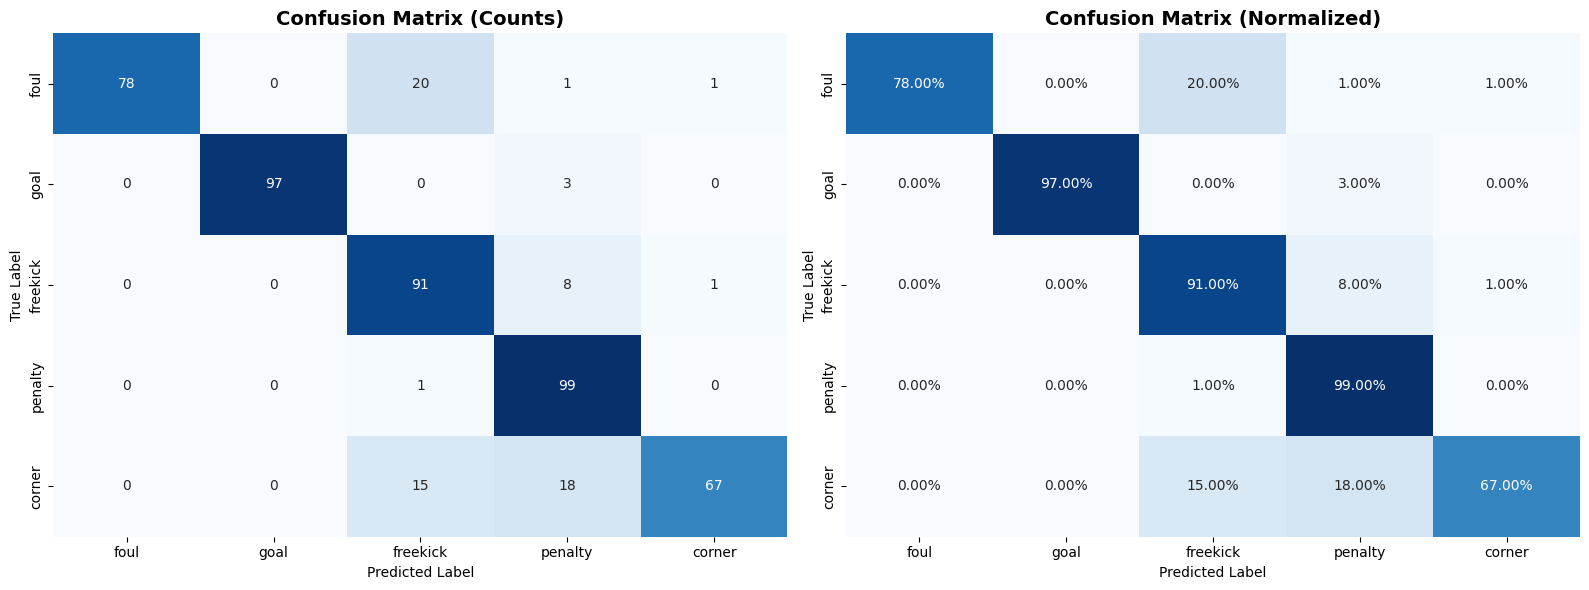

✓ Saved: test_confusion_matrix.png


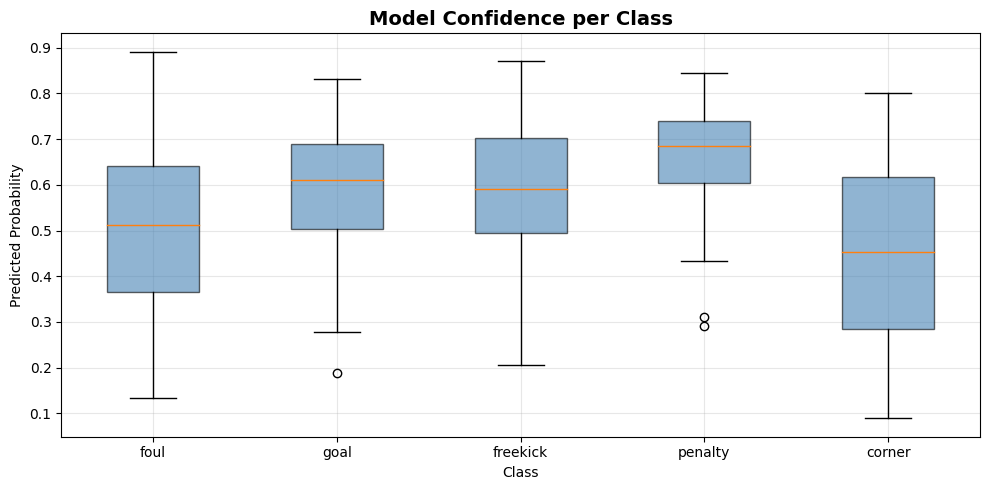

✓ Saved: test_confidence.png

✅  Testing complete!



In [8]:
"""
Football Action Classification - Model Testing Script
Tests saved model on validation/test data and prints full metrics
"""

import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1.  DOWNLOAD MODEL FROM GOOGLE DRIVE
# ─────────────────────────────────────────────
# Paste your Google Drive shareable link file-id below
# e.g. https://drive.google.com/file/d/FILE_ID/view?usp=sharing  →  FILE_ID
DRIVE_SHARE_URL = "https://drive.google.com/file/d/1GStgg3zr2BpG6qiARFbl6xJOsSn_kjG8/view?usp=sharing"
MODEL_SAVE_PATH = "/kaggle/working/football_action_model.pth"

def download_model_from_drive(share_url, output_path):
    if os.path.exists(output_path):
        print(f"✓ Model already exists at {output_path}, skipping download.")
        return
    print("📥 Downloading model from Google Drive...")
    os.system('pip install -q gdown --upgrade')
    import gdown
    # fuzzy=True handles /view?usp=sharing URLs directly
    gdown.download(share_url, output_path, quiet=False, fuzzy=True)
    if not os.path.exists(output_path):
        raise RuntimeError(
            "Download failed. Please go to your Google Drive file → Share → "
            "Change to 'Anyone with the link' → Copy link, then update DRIVE_SHARE_URL."
        )
    print(f"✓ Model downloaded to {output_path}")

download_model_from_drive(DRIVE_SHARE_URL, MODEL_SAVE_PATH)


# ─────────────────────────────────────────────
# 2.  CONFIG  (must match training config)
# ─────────────────────────────────────────────
CONFIG = {
    'data_path': '/kaggle/input/highlights',
    'model_name': 'swinv2_base_window12_192_22k',
    'num_classes': 5,
    'num_frames': 48,
    'img_size': 192,
    'batch_size': 4,           # increase if your GPU has room
    'num_workers': 2,
    'dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'temporal_attention_heads': 8,
    'lstm_layers': 2,
    'hidden_multiplier': 2,
    'focal_loss_gamma': 2.5,
    'focal_loss_alpha': 0.75,
    'label_smoothing': 0.15,
}

CLASSES = ['foul', 'goal', 'freekick', 'penalty', 'corner']


# ─────────────────────────────────────────────
# 3.  MODEL ARCHITECTURE  (copy from training)
# ─────────────────────────────────────────────

class ContextAwareTemporalModule(nn.Module):
    def __init__(self, feature_dim, num_frames, dropout=0.3):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_frames = num_frames
        # Named pyramid_1/2/3/4 to match training checkpoint keys
        self.pyramid_1 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_2 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=5, padding=2),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_3 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=7, padding=3),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.pyramid_4 = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim // 4, kernel_size=11, padding=5),
            nn.BatchNorm1d(feature_dim // 4), nn.GELU(), nn.Dropout(dropout * 0.5)
        )
        self.fusion = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim, kernel_size=1),
            nn.BatchNorm1d(feature_dim), nn.GELU()
        )

    def forward(self, x):
        x_t = x.transpose(1, 2)
        p1 = self.pyramid_1(x_t)
        p2 = self.pyramid_2(x_t)
        p3 = self.pyramid_3(x_t)
        p4 = self.pyramid_4(x_t)
        return self.fusion(torch.cat([p1, p2, p3, p4], dim=1)).transpose(1, 2)


class EnhancedVideoTransformer(nn.Module):
    def __init__(self, model_name, num_classes, num_frames=48, dropout=0.5):
        super().__init__()
        self.num_frames = num_frames
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0, global_pool='avg')
        self.feature_dim = self.backbone.num_features

        self.context_temporal = ContextAwareTemporalModule(self.feature_dim, num_frames, dropout)

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=self.feature_dim // 2,
            num_layers=CONFIG['lstm_layers'],
            batch_first=True, bidirectional=True,
            dropout=dropout * 0.5 if CONFIG['lstm_layers'] > 1 else 0
        )

        heads = CONFIG['temporal_attention_heads']
        while self.feature_dim % heads != 0:
            heads -= 1
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=self.feature_dim, num_heads=heads,
            dropout=dropout * 0.5, batch_first=True
        )

        self.frame_weights = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim // 4), nn.GELU(),
            nn.Dropout(dropout * 0.5), nn.Linear(self.feature_dim // 4, 1), nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim), nn.Dropout(dropout),
            nn.Linear(self.feature_dim, self.feature_dim * CONFIG['hidden_multiplier']),
            nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(self.feature_dim * CONFIG['hidden_multiplier'], self.feature_dim),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(self.feature_dim, self.feature_dim // 2),
            nn.GELU(), nn.Dropout(dropout * 0.3),
            nn.Linear(self.feature_dim // 2, num_classes)
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        features = self.backbone(x.view(b * t, c, h, w)).view(b, t, -1)
        ctx = self.context_temporal(features)
        lstm_out, _ = self.lstm(ctx)
        attn_out, _ = self.temporal_attention(lstm_out, lstm_out, lstm_out)
        combined = features + ctx + lstm_out + attn_out
        w = self.frame_weights(combined)
        weighted = combined * w
        pooled = weighted.mean(dim=1) + 0.3 * weighted.max(dim=1).values
        return self.classifier(pooled)


# ─────────────────────────────────────────────
# 4.  DATASET
# ─────────────────────────────────────────────

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=48, img_size=192):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.video_paths)

    def extract_frames(self, path):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, max(1, total - 1), self.num_frames, dtype=int)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            elif frames:
                frames.append(frames[-1].copy())
        cap.release()
        while len(frames) < self.num_frames:
            frames.append(frames[-1].copy() if frames else
                          np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        return frames[:self.num_frames]

    def __getitem__(self, idx):
        frames = self.extract_frames(self.video_paths[idx])
        tensor = torch.stack([self.transform(f) for f in frames])
        return tensor, self.labels[idx]


# ─────────────────────────────────────────────
# 5.  LOAD TEST DATA
# ─────────────────────────────────────────────

def load_test_data(data_path, videos_per_class=100):
    """Load exactly 100 videos per class for testing."""
    class_to_idx = {cls: idx for idx, cls in enumerate(CLASSES)}
    paths, labels = [], []
    
    np.random.seed(42)  # reproducible selection
    
    for cls in CLASSES:
        cls_path = os.path.join(data_path, cls)
        if not os.path.exists(cls_path):
            print(f"⚠ Missing: {cls_path}")
            continue
        
        videos = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi', '.mov'))]
        
        if len(videos) >= videos_per_class:
            selected = np.random.choice(videos, videos_per_class, replace=False).tolist()
        else:
            # if less than 100 available, take all and oversample
            selected = videos + np.random.choice(videos, videos_per_class - len(videos), replace=True).tolist()
            print(f"  ⚠ {cls}: only {len(videos)} available, oversampled to {videos_per_class}")
        
        print(f"  {cls}: {len(selected)} videos selected")
        for v in selected:
            paths.append(os.path.join(cls_path, v))
            labels.append(class_to_idx[cls])
    
    print(f"  Total: {len(paths)} videos ({videos_per_class} per class)\n")
    return paths, labels


# ─────────────────────────────────────────────
# 6.  INFERENCE
# ─────────────────────────────────────────────

def run_inference(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for videos, labels in tqdm(loader, desc='Running inference'):
            videos = videos.to(device, non_blocking=True)
            outputs = model(videos)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            del videos, outputs
            torch.cuda.empty_cache()
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


# ─────────────────────────────────────────────
# 7.  METRICS + PLOTS
# ─────────────────────────────────────────────

def print_metrics(preds, labels, probs):
    print("\n" + "="*70)
    print("📊  FULL CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(labels, preds, target_names=CLASSES, digits=4))

    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro')

    print("="*70)
    print(f"  Overall Accuracy      : {acc*100:.4f}%")
    print(f"  Weighted Precision    : {p*100:.4f}%")
    print(f"  Weighted Recall       : {r*100:.4f}%")
    print(f"  Weighted F1-Score     : {f1*100:.4f}%")
    print(f"  Macro Precision       : {p_macro*100:.4f}%")
    print(f"  Macro Recall          : {r_macro*100:.4f}%")
    print(f"  Macro F1-Score        : {f1_macro*100:.4f}%")
    print("="*70)

    # Per-class breakdown
    print("\n📌  PER-CLASS METRICS")
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-"*55)
    p_c, r_c, f1_c, sup = precision_recall_fscore_support(labels, preds, average=None)
    for i, cls in enumerate(CLASSES):
        print(f"{cls:<12} {p_c[i]*100:>9.2f}%  {r_c[i]*100:>8.2f}%  {f1_c[i]*100:>8.2f}%  {int(sup[i]):>9}")


def plot_confusion_matrices(preds, labels):
    cm = confusion_matrix(labels, preds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('test_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: test_confusion_matrix.png")


def plot_class_confidence(probs, labels):
    """Box plot of model confidence per class."""
    fig, ax = plt.subplots(figsize=(10, 5))
    data = [probs[labels == i, i] for i in range(len(CLASSES))]
    ax.boxplot(data, labels=CLASSES, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title('Model Confidence per Class', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Probability'); ax.set_xlabel('Class')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('test_confidence.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: test_confidence.png")


# ─────────────────────────────────────────────
# 8.  MAIN
# ─────────────────────────────────────────────

def main():
    device = CONFIG['device']
    print(f"\n{'='*70}")
    print("🏆  FOOTBALL ACTION MODEL - TESTING")
    print(f"{'='*70}")
    print(f"Device : {device}")
    if device == 'cuda':
        print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print()

    # Load model
    print("🔧 Loading model...")
    model = EnhancedVideoTransformer(
        CONFIG['model_name'], CONFIG['num_classes'],
        CONFIG['num_frames'], CONFIG['dropout']
    ).to(device)

    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    saved_acc = checkpoint.get('val_acc', 'N/A')
    saved_epoch = checkpoint.get('epoch', 'N/A')
    print(f"✓ Loaded checkpoint  — epoch {saved_epoch}, val_acc {saved_acc}")

    # Load test data
    print("\n📂 Loading test data...")
    test_paths, test_labels = load_test_data(CONFIG['data_path'], videos_per_class=100)

    dataset = VideoDataset(test_paths, test_labels, CONFIG['num_frames'], CONFIG['img_size'])
    loader  = DataLoader(dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=CONFIG['num_workers'],
                         pin_memory=True)

    # Inference
    preds, labels, probs = run_inference(model, loader, device)

    # Metrics
    print_metrics(preds, labels, probs)

    # Plots
    plot_confusion_matrices(preds, labels)
    plot_class_confidence(probs, labels)

    print(f"\n{'='*70}")
    print("✅  Testing complete!")
    print(f"{'='*70}\n")


if __name__ == "__main__":
    main()